In [1]:
import pandas as pd 
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import KFold, cross_val_score      # to use KFold and func: cross_val_score 
import numpy as np

In [2]:
dataset=pd.read_csv("50_Startups.csv")

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
dataset=pd.get_dummies(dataset, drop_first=True, dtype=int)

In [5]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [7]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [8]:
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [9]:
dependent=dataset[['Profit']]

In [10]:
regressor=DecisionTreeRegressor()

In [11]:
#-----------K-Fold--------------#
kfold=KFold(n_splits=5, shuffle=True, random_state=0)

scores=cross_val_score(
estimator=regressor, X=independent, y=dependent, cv=kfold, scoring="r2")
#-----------K-Fold--------------#
print("="*60)
print("R2 Score for each fold:", scores)
print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())
print("="*60)

R2 Score for each fold: [0.97355727 0.87665402 0.84085212 0.84960525 0.91048449]
Mean R2: 0.8902306291658061
Standard Deviation: 0.048221428550501114


In [15]:
regressor.fit(independent, dependent)

DecisionTreeRegressor()

K-Fold R2 Scores: [0.97245618 0.82528048 0.76940453 0.93313938 0.87542348]
Mean R2: 0.8751408091299029


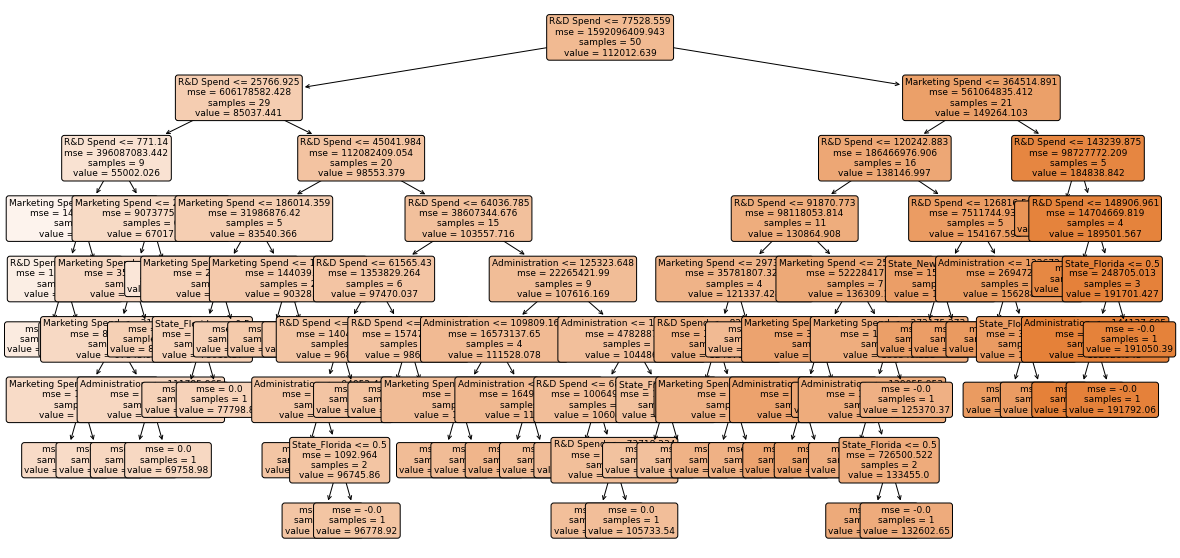

In [18]:
regressor = DecisionTreeRegressor(random_state=0)

scores = cross_val_score(
    regressor,
    independent,
    dependent,
    cv=kfold,
    scoring="r2"
)

print("K-Fold R2 Scores:", scores)
print("Mean R2:", scores.mean())

# Fit final model for visualization
regressor.fit(independent, dependent)

plt.figure(figsize=(20, 10))
tree.plot_tree(
    regressor,
    feature_names=independent.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

In [19]:
from sklearn.tree import export_text

regressor.fit(independent, dependent)

rules = export_text(
    regressor,
    feature_names=list(independent.columns),
    max_depth=3
)

print(rules)

|--- R&D Spend <= 77528.56
|   |--- R&D Spend <= 25766.92
|   |   |--- R&D Spend <= 771.14
|   |   |   |--- Marketing Spend <= 22586.53
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Marketing Spend >  22586.53
|   |   |   |   |--- value: [14681.40]
|   |   |--- R&D Spend >  771.14
|   |   |   |--- Marketing Spend <= 241189.78
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Marketing Spend >  241189.78
|   |   |   |   |--- value: [49490.75]
|   |--- R&D Spend >  25766.92
|   |   |--- R&D Spend <= 45041.98
|   |   |   |--- Marketing Spend <= 186014.36
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Marketing Spend >  186014.36
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- R&D Spend >  45041.98
|   |   |   |--- R&D Spend <= 64036.79
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- R&D Spend >  64036.79
|   |   |   |   |--- truncated branch of depth 5
|--- R&D Spend >  77528.56
|   |--- Marketing Spend